# Resource estimation for quantum phase estimation of a $J_1$–$J_2$ Heisenberg model

In this notebook we demonstrate how to estimate the resources for quantum phase estimation (QPE), specifically standard QPE of a frustrated $J_1$–$J_2$ Heisenberg Hamiltonian on an open
$N \times N$ square lattice, using a fourth-order Trotter-Suzuki product formula for the controlled time evolution.

The Hamiltonian terms are organized into lattice-aware commuting groups and parallel layers prior to Trotterization, which exploits the lattice structure of the model to make the circuit cheaper to run fault-tolerantly.

We use:
- **qdk-chemistry** for all domain-specific functionality (lattice geometry, model Hamiltonians, standard phase estimation, circuit construction)
- **qdk.qre** for quantum resource estimation

## Background: $J_1$–$J_2$ Heisenberg model

The Heisenberg model describes localized spins coupled by isotropic exchange. On the square lattice, an antiferromagnetic nearest-neighbor coupling $J_1$ favors Néel order, while a next-nearest-neighbor (diagonal) coupling $J_2$ frustrates it. Frustration is strongest near $J_2/J_1 = 0.5$, where the nature of the ground state is still debated, which makes this regime a long-standing challenge for classical methods.
Writing $\langle i, j\rangle_n$ for the $n$-th-neighbor bonds, the Hamiltonian we consider is:

$$
H = J_1 \sum_{\langle i, j\rangle_1} \mathbf{S}_i\cdot\mathbf{S}_j + J_2 \sum_{\langle i, j\rangle_2} \mathbf{S}_i\cdot\mathbf{S}_j
$$
where first-neighbor bonds join horizontally and vertically adjacent sites, second-neighbor bonds join diagonally adjacent sites, and $\mathbf{S}_i = \boldsymbol{\sigma}_i / 2$. We use $J_1 = 1$ and $J_2 = 0.5$, so energies are in units of $J_1$ and times in units of $\hbar / J_1$.

## Creating the Heisenberg model

We use `qdk_chemistry` to define the lattice geometry and build the
Hamiltonian. `LatticeGeometry.square` creates an open square lattice, and
`LatticeGraph.from_geometry` labels its first- and second-neighbor bonds by
distance shell. `create_heisenberg_hamiltonian` takes a coupling for each
shell and produces the corresponding `QubitOperator`. The operator is written
in Pauli matrices, so each coupling is $J_n/4$, from
$\mathbf{S}_i\cdot\mathbf{S}_j = (X_iX_j + Y_iY_j + Z_iZ_j)/4$.

By default `create_heisenberg_hamiltonian` stores a lattice-aware
group-and-layer structure on `QubitOperator.term_partition`
(strategy `geometry_coloring`). Terms in a group commute, and terms in the
same layer act on disjoint qubits, so the corresponding Pauli exponentials
can be applied in parallel. Here the XX, YY, and ZZ terms each form one
commuting group, whose layers follow an edge coloring of the lattice.

In [1]:
from qdk_chemistry.algorithms import create
from qdk_chemistry.data import AlgorithmRef, LatticeGeometry, LatticeGraph
from qdk_chemistry.utils.model_hamiltonians import create_heisenberg_hamiltonian

# Reduce logging output for demo
from qdk_chemistry.utils import Logger
Logger.set_global_level(Logger.LogLevel.off)

# Lattice dimensions, in sites
nx, ny = 10, 10
geometry = LatticeGeometry.square(nx, ny, periodic_x=False, periodic_y=False)
lattice = LatticeGraph.from_geometry(geometry, shells=[1, 2])

j1, j2 = 1.0, 0.5  # J2/J1 = 0.5: strongest frustration
pauli_couplings = {1: j1 / 4, 2: j2 / 4}  # S_i·S_j = (XX + YY + ZZ)/4, by neighbor shell

hamiltonian = create_heisenberg_hamiltonian(
    lattice,
    jx=pauli_couplings,
    jy=pauli_couplings,
    jz=pauli_couplings,
    include_term_groups=True,
)

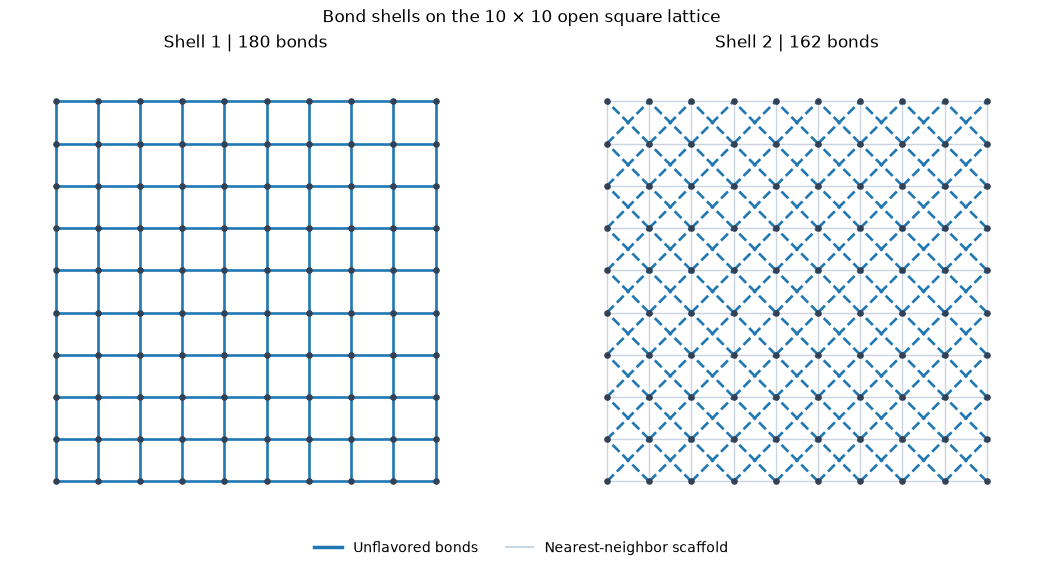

In [2]:
import matplotlib.pyplot as plt

from utils.lattice_plotting import plot_lattice_graph

fig, axes = plot_lattice_graph(
    lattice,
    geometry.positions,
    title=f"Bond shells on the {nx} × {ny} open square lattice",
)
plt.show()

## Building the phase estimation circuit

We use the standard (QFT-based) `qpe_circuit_builder` to construct the phase
estimation circuit without executing it. All sub-algorithms are specified via
`AlgorithmRef` factories:

| Setting | Algorithm | Purpose |
|---------|-----------|---------|
| `unitary_builder` | `trotter` (order 4, 10 divisions) | Suzuki product formula for $U = e^{-iHt}$ |
| `controlled_circuit_mapper` | `pauli_sequence` | Compiles each controlled $U^{2^k}$ to Q# / QIR |

The circuit prepares the system register, puts 10 phase qubits in a uniform
superposition, applies controlled $U^{2^k}$ for $k = 0, \ldots, 9$, and
finishes with an inverse QFT and phase-register measurements. $U$ evolves for
$t = 1\,\hbar/J_1$ in 10 fourth-order Trotter steps of $0.1\,\hbar/J_1$, and
`power_strategy="repeat"` builds each power by repeating that product formula,
so the largest power, $U^{512}$, takes 5,120 steps. The product formula stores
one step with its repetition count rather than every copy, which keeps circuit
construction and resource estimation fast. Exporting the circuit as Q# or QIR
text would expand every repetition, so we skip that here.

Two `trotter` options shorten the product formula while keeping its fourth
order and step count. `minimize_pauli_exponentials` reorders the commuting
groups within each step to need as few Pauli exponentials as possible, and
`fuse_group_boundaries` merges the group that ends each step with the
identical group that starts the next, including across the repetitions that
build each power. The XX, YY, and ZZ groups of the Heisenberg model are the
same size, so reordering cannot help here, and only the fusion shortens the
formula.

The identity state preparation $|0\cdots0\rangle$ is a placeholder for
resource counting; estimating an energy requires a state with good overlap
with the target eigenstate. The evolution time, step size, and number of phase
bits are illustrative rather than calibrated for a target energy accuracy.

In [3]:
from qdk_chemistry.algorithms.state_preparation import identity_state_prep

num_bits = 10  # phase-register qubits
t = 1.0  # evolution time of U (ħ/J1)
dt = 0.1  # Trotter step size (ħ/J1)
num_steps = round(t / dt)

unitary_builder = AlgorithmRef(
    "hamiltonian_unitary_builder", "trotter",
    time=t, order=4, num_divisions=num_steps, power_strategy="repeat",
    minimize_pauli_exponentials=True, fuse_group_boundaries=True,
)
circuit_mapper = AlgorithmRef("controlled_circuit_mapper", "pauli_sequence")

circuit_builder = create(
    "qpe_circuit_builder", "qdk_standard",
    num_bits=num_bits,
    unitary_builder=unitary_builder,
    controlled_circuit_mapper=circuit_mapper,
)

# Identity state prep: |0...0⟩ (all spins up in Z basis)
state_prep = identity_state_prep(num_qubits=hamiltonian.num_qubits)

# Build the standard QPE circuit without executing; the builder returns a one-element list.
circuit = circuit_builder.run(state_preparation=state_prep, qubit_hamiltonian=hamiltonian)[0]

print(f"QPE: {num_bits} phase bits; U = {num_steps} fourth-order Trotter steps of {dt}; "
      f"largest power U^{2 ** (num_bits - 1)}")

QPE: 10 phase bits; U = 10 fourth-order Trotter steps of 0.1; largest power U^512


## Application wrapper

To obtain resource estimates we wrap the circuit in a QRE `Application`
instance. The `Circuit.get_qre_application()` method handles this
automatically, choosing the appropriate application type based on the
available circuit representation.

In [4]:
app = circuit.get_qre_application()

## Majorana architectures

A QRE `Architecture` is a container for an Instruction Set Architecture (ISA): a list of instructions the hardware supports. The Majorana architecture supports single-qubit and two-qubit measurements in the X- and Z-bases, as well as a timing-based T-gate. The `Majorana` subclass provides the ISA for a user specified measurement error rate. Note the asymmetry in the assumed error rates for measurement/state preparation versus the unitary T-gate.

In [5]:
from qdk.qre.models import Majorana

arch = Majorana(error_rate=1e-5)
arch

Majorana(error_rate=1e-05, time=1000, t_error_rate=0.015, target_year=None)

## Creating Application and ISA Queries

The core of the system is modeled through trace queries (from the top) and isa_queries (from the bottom).

The trace query applies layouts (`ISATransform` instances) to convert the operations from the application into logical operations supported by error correction codes and magic state factories. Here we expand fine rotation gates into T-gates using circuit synthesis. The `PSSPC` layout takes as an argument the options for the number of T-gates used per rotation. QRE will enumerate over this list and compute the error rate associated to each approximation, and the contribution to the overall error rate. The `LatticeSurgery` layout links the cat-state layout (which requires instruction MULTI_PAULI_MEAS) to the logical operation provided by the code (LATTICE_SURGERY). Its `slow_down_factor` option lets QRE deliberately stretch each logical operation in time, trading a longer runtime for far fewer magic-state factories (and hence fewer qubits); `slow_down_factor = 1` runs as fast as possible.

The ISA query provides the specific options for the code, in this case `ThreeAux` (an instance of the surface code). It provides the LATTICE_SURGERY instruction required by the trace. Magic states are not provided by the code, and so the `RoundBasedFactory` is a generic model that provides magic state distillation.

In [6]:
from qdk.qre import estimate, plot_estimates, PSSPC, LatticeSurgery
from qdk.qre.models import ThreeAux, RoundBasedFactory
from qdk.qre.instruction_ids import LATTICE_SURGERY
from qdk.qre.property_keys import NUM_TS_PER_ROTATION, DISTANCE, PHYSICAL_COMPUTE_QUBITS

# Sweep over rotation-synthesis precision (num_ts_per_rotation) and the
# lattice-surgery slow_down_factor.  Higher slow_down trades longer runtime
# for fewer magic-state factories (and hence fewer qubits).
num_ts_per_rotation = list(range(20, 45, 2))
slow_down_factor = [1.0 * j for j in range(1, 20)]

trace_query = (
    app.q()
    * PSSPC.q(num_ts_per_rotation=num_ts_per_rotation)
    * LatticeSurgery.q(slow_down_factor=slow_down_factor)
)

isa_query = ThreeAux.q() * RoundBasedFactory.q(code_query=ThreeAux.q())

results = estimate(app, arch, isa_query, trace_query, max_error=0.01, name="J1–J2 Heisenberg")
results.add_column("compute_distance", lambda entry: entry.source[LATTICE_SURGERY].instruction[DISTANCE])
results.add_column("compute qubits", lambda entry: entry.properties[PHYSICAL_COMPUTE_QUBITS])
results.add_column("num_ts_per_rotation", lambda entry: entry.properties[NUM_TS_PER_ROTATION])
results.add_factory_summary_column()

results.as_frame()

,name,qubits,runtime,error,compute_distance,compute qubits,num_ts_per_rotation,factories
0,J1–J2 Heisenberg,286681,2 days 08:30:45.852379,0.009677,9,80571,24,10×T
1,J1–J2 Heisenberg,302427,2 days 05:32:18.175938,0.009598,9,80571,24,12×T
2,J1–J2 Heisenberg,320915,2 days 02:33:50.499497,0.009518,9,80571,24,13×T
3,J1–J2 Heisenberg,327903,1 days 23:35:22.823056,0.009439,9,80571,24,12×T
4,J1–J2 Heisenberg,339403,1 days 20:36:55.146615,0.009359,9,80571,24,14×T
5,J1–J2 Heisenberg,348514,1 days 19:42:17.286480,0.008561,9,80571,24,13×T
6,J1–J2 Heisenberg,357891,1 days 17:38:27.470174,0.009280,9,80571,24,15×T
7,J1–J2 Heisenberg,369125,1 days 17:16:36.326120,0.008539,9,80571,24,14×T
8,J1–J2 Heisenberg,389736,1 days 14:39:59.793733,0.009200,9,80571,24,15×T
9,J1–J2 Heisenberg,410347,1 days 11:41:32.117292,0.009121,9,80571,24,16×T


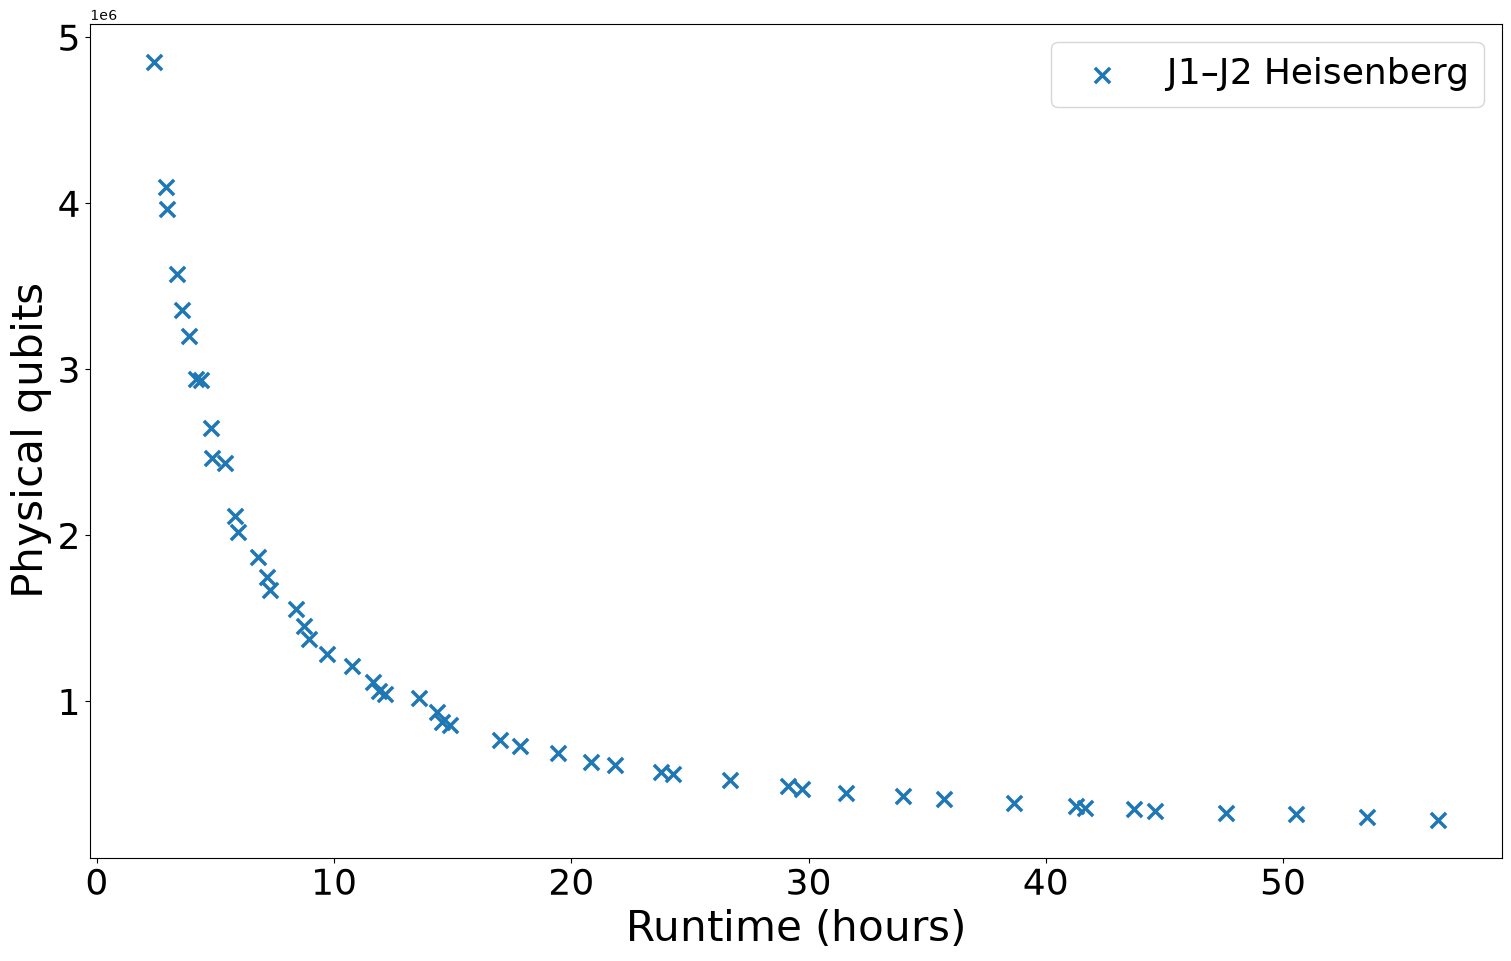

In [7]:
fig = plot_estimates([results], runtime_unit="hours", figsize=(15, 9.5),
                     scatter_args={"marker": "x", "s": 120, "linewidths": 2.5})
ax = fig.axes[0]
ax.set_xscale("linear")
ax.set_yscale("linear")
ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.set_ylabel(ax.get_ylabel(), fontsize=30)
ax.tick_params(axis="both", labelsize=26)
ax.legend(fontsize=26, loc="upper right")
fig.set_layout_engine("constrained")
fig